# Task 1: Article-Type Classification


## 1. Introduction

This notebook addresses **Task 1: Article-Type Classification** for Assignment 2 by predicting the article type of a fashion product from its RGB image, such as a shirt, dress, or pair of shoes. The task is formulated as **a multi-class image classification problem: each image receives one catalogue article-type label**.

Three neural-network approaches are developed and trained from scratch using TensorFlow/Keras:

- **Shallow MLP (Baseline):** A fully connected network with one 256-unit hidden layer operating on flattened image pixels.
- **Deeper MLP:** A fully connected network with hidden layers of 256, 128, and 64 units, using dropout to reduce overfitting.
- **Convolutional Neural Network (CNN):** A spatial model that learns local image patterns through convolutional layers. The CNN family includes three declared architecture/scheduling configurations.

Performance is assessed using:

- **Accuracy:** The proportion of correctly classified images.
- **Macro-F1:** The primary selection metric, giving equal weight to the F1 scores of classes present in the evaluation partition.
- **Per-class classification reports and confusion matrices:** Evidence of which labels are recognized reliably and which are confused.
- **Learning curves:** Training and validation loss, accuracy, and macro-F1 used to examine convergence and overfitting.
- **Calibration metrics:** Confidence reliability of the selected model, assessed after selection using separate validation groups.

Article categories can share silhouettes and textures, while rare categories have fewer training examples. The analysis therefore considers class support and common confusions alongside overall accuracy.

The workflow covers metadata inspection, preprocessing, model development, comparative evaluation, selection, and export for prediction. All candidates use the same frozen group-isolated data partitions. The internal test has prior development exposure, which remains a limitation after retraining. Numerical findings and the final model judgment must be completed from the new executed results; no winner is assumed in advance.


## 2. Library Imports & Setup

Use the Fashion Keras kernel. The seed controls initialization and augmentation. Float32 is used throughout; GPU availability is reported before models are created.


In [1]:
from pathlib import Path
import sys, json
from concurrent.futures import ThreadPoolExecutor
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance
from IPython.display import display
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support, classification_report, log_loss, ConfusionMatrixDisplay
from sklearn.model_selection import GroupShuffleSplit
from scipy.optimize import minimize_scalar
import tensorflow as tf
from tensorflow import keras
from scripts.preprocessing import task_frame, IMAGE_SIZE, NORMALISATION_PATH, SEED, select_tensorflow_device
DEVICE = select_tensorflow_device()
keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()
OUTPUT, RESULTS, FIGURES = (ROOT / 'models', ROOT / 'results', ROOT / 'figures')
for directory in (OUTPUT, RESULTS, FIGURES):
    directory.mkdir(parents=True, exist_ok=True)
MAX_EPOCHS, BATCH_SIZE = (30, 64)

def stem_for(target):
    return 'article_type' if target == 'articleType' else target
# False for a fresh Run All. Enable only when deliberately resuming matching saved experiments.
RESUME_SAVED_RESULTS = False

get_ipython().run_line_magic('matplotlib', 'inline')


2026-09-11 11:16:38.442839: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-11 11:16:38.487929: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-09-11 11:16:39.338763: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.20.0: /GPU:0


## 3. Load Metadata

Load valid labelled images and their frozen split assignments. Inspect paths, target labels and missing values before preprocessing.


In [2]:
metadata_by_target = {'articleType': task_frame('articleType')}
frame = metadata_by_target['articleType']
print('articleType', frame.shape)
display(frame.head())

articleType (38611, 15)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,productDisplayName_repaired,image_path,has_image,group_key,split
0,1163,Men,Apparel,Topwear,Tshirts,Blue,Summer,2011,Sports,Nike Sahara Team India Fanwear Round Neck Jersey,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_0,train
1,1164,Men,Apparel,Topwear,Tshirts,Blue,Winter,2015,Sports,Nike Men Blue T20 Indian Cricket Jersey,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_1,train
2,1165,Men,Apparel,Topwear,Tshirts,Blue,Summer,2013,Sports,Nike Mean Team India Cricket Jersey,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_2,train
3,1525,Unisex,Accessories,Bags,Backpacks,Navy Blue,Fall,2010,Casual,Puma Deck Navy Blue Backpack,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_3,train
4,1526,Unisex,Accessories,Bags,Backpacks,Black,Fall,2010,Sports,Puma Big Cat Backpack Black,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_4,train


## 4. Data Preprocessing

Prepare the same images and label encoding for every candidate. Preserve group isolation and fit normalization on training data only.


### 4.1. Class Distribution & Balancing Strategy

Preserve the original sample distribution. Initial candidates use unweighted cross-entropy; additional CNN experiments compare this with capped square-root inverse-frequency weights computed only from training counts. No examples are duplicated, and validation metrics remain unweighted.


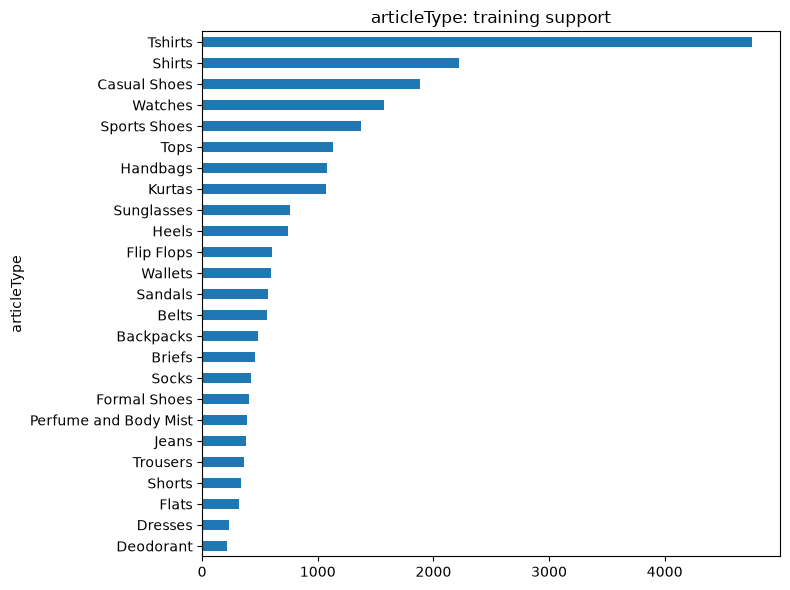

In [ ]:
train_rows = metadata_by_target['articleType'].loc[metadata_by_target['articleType']['split'].eq('train')]
counts = train_rows['articleType'].value_counts()
counts.head(25).sort_values().plot.barh(figsize=(8, 6), title=f"{'articleType'}: training support")
plt.tight_layout()
plt.show()

### 4.2. Training, Validation & Test Partitions

Reuse the frozen product-group split. Within validation, use separate groups for selection, temperature fitting and policy checking. Do not use the internal test to select candidates.


In [3]:
def validation_views(frame):
    selection_ids, rest_ids = next(GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=SEED)
                                   .split(frame, groups=frame.group_key))
    selection, rest = frame.iloc[selection_ids], frame.iloc[rest_ids]
    cal_ids, policy_ids = next(GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=SEED + 1)
                              .split(rest, groups=rest.group_key))
    return selection, rest.iloc[cal_ids], rest.iloc[policy_ids]

In [4]:
frames, labels_by_target = ({}, {})
selection, calibration, policy = validation_views(metadata_by_target['articleType'].loc[metadata_by_target['articleType']['split'].eq('validation')])
frames['articleType'] = dict(train=metadata_by_target['articleType'].loc[metadata_by_target['articleType']['split'].eq('train')], selection=selection, calibration=calibration, policy=policy)
groups = [set(frame.group_key) for frame in frames['articleType'].values()]
assert all((a.isdisjoint(b) for i, a in enumerate(groups) for b in groups[i + 1:]))
labels_by_target['articleType'] = sorted(frames['articleType']['train']['articleType'].unique())
display(pd.Series({name: len(frame) for name, frame in frames['articleType'].items()}, name='articleType'))

train          27051
selection       2900
calibration     1378
policy          1564
Name: articleType, dtype: int64

### 4.3. Image Preprocessing

Resize RGB to 96 x 128 pixels (width x height), then normalize using training-only channel statistics. The batch class stores decoded uint8 images and converts one batch at a time to float32. Horizontal flips are applied inside each model only during training.


In [5]:
class CachedBatches(keras.utils.PyDataset):
    """Decode RGB once to uint8 RAM, then normalize each NHWC batch."""
    def __init__(self, frame, target, labels, normalisation, training=False, batch_size=64):
        super().__init__(workers=0, max_queue_size=2)
        self.dataset = frame
        self.training, self.batch_size = training, batch_size
        def read(path):
            with Image.open(path) as image:
                return np.asarray(image.convert("RGB").resize(IMAGE_SIZE, Image.Resampling.BILINEAR)).copy()
        with ThreadPoolExecutor(max_workers=4) as pool:
            self.images = np.stack(list(pool.map(read, frame.image_path)))
        self.targets = np.asarray([labels.index(label) for label in frame[target]], dtype=np.int32)
        self.mean = np.asarray(normalisation["mean"], dtype=np.float32)
        self.std = np.asarray(normalisation["std"], dtype=np.float32)
        self.reset()

    def reset(self):
        self.rng = np.random.default_rng(SEED)
        self.indices = np.arange(len(self.dataset))
        if self.training:
            self.rng.shuffle(self.indices)

    def __len__(self):
        return (len(self.dataset) + self.batch_size - 1) // self.batch_size

    def __getitem__(self, index):
        ids = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        images = self.images[ids].astype(np.float32) / 255.0
        return (images - self.mean) / self.std, self.targets[ids]

    def on_epoch_end(self):
        if self.training:
            self.rng.shuffle(self.indices)

### 4.4. Feature Batches & Label Encoding

Map sorted label names to integer indices, preserving the same order for every model. Construct shuffled training batches and fixed-order selection batches.


In [6]:
normalisation = json.loads(NORMALISATION_PATH.read_text())
loaders = {}
labels = labels_by_target['articleType']
loaders['articleType'] = {name: CachedBatches(frames['articleType'][name], 'articleType', labels, normalisation, training=name == 'train', batch_size=BATCH_SIZE) for name in ['train', 'selection']}

## 5. Model Development & Evaluation

This section develops three neural-network families trained from scratch on the supplied fashion images. Moving from flattened pixels to deeper dense layers and then spatial convolutions lets us examine how architecture affects performance under the same evaluation protocol.

**Models included:**

- **5.1. Shallow MLP (Baseline):** Establishes the performance of one hidden layer on flattened RGB input.
- **5.2. Deeper MLP:** Tests whether additional dense layers improve the learned representation and generalization.
- **5.3. Convolutional Neural Network (CNN):** Learns spatial features and compares the declared convolutional configurations and learning-rate schedules.

Each model subsection shows its architecture, compilation, and training code. All candidates use the same image size, normalization, batch size, training/selection groups, Adam optimizer, and maximum epoch budget. Training-only horizontal flips and dropout provide regularization. Early stopping restores the epoch with the highest selection macro-F1; scheduled CNNs additionally reduce the learning rate when that metric stalls.

The following subsections compare the restored models, plot learning curves, and evaluate the selected model. Model selection prioritizes **validation macro-F1**, then accuracy, then parameter count. Calibration and review thresholds use separate validation groups. The internal test is evaluated after selection and must not be used to choose an architecture.


### Evaluation Metric: Macro-F1

Accumulate the full-epoch confusion matrix and average F1 over classes with positive ground-truth support. This metric selects the restored epoch and winning model. It does not average per-batch F1 scores.

The displayed per-class classification report also includes every output label for coverage auditing. Its standard `macro avg` row therefore includes zero-support output labels and can differ from the supported-class macro-F1 used for selection. Read the explicitly reported selection metric for model ranking, and inspect support before making claims about all classes. Selection support is 97/124 article types, 4/4 seasons, 5/5 gender categories and 8/9 occasion labels for this frozen run.


In [5]:
@keras.utils.register_keras_serializable(package="Fashion")
class SupportedMacroF1(keras.metrics.Metric):
    """Macro-F1 over classes present in the full epoch's ground truth."""
    def __init__(self, num_classes, name="macro_f1", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.matrix = self.add_weight(name="matrix", shape=(num_classes, num_classes), initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        truth = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        predictions = tf.argmax(y_pred, axis=-1, output_type=tf.int32)
        weights = None if sample_weight is None else tf.cast(tf.reshape(sample_weight, [-1]), self.dtype)
        self.matrix.assign_add(tf.math.confusion_matrix(truth, predictions, self.num_classes,
                                                        weights=weights, dtype=self.dtype))

    def result(self):
        support = tf.reduce_sum(self.matrix, axis=1)
        predicted = tf.reduce_sum(self.matrix, axis=0)
        f1 = tf.math.divide_no_nan(2 * tf.linalg.diag_part(self.matrix), support + predicted)
        mask = tf.cast(support > 0, self.dtype)
        return tf.math.divide_no_nan(tf.reduce_sum(f1 * mask), tf.reduce_sum(mask))

    def reset_state(self):
        self.matrix.assign(tf.zeros_like(self.matrix))

    def get_config(self):
        return {**super().get_config(), "num_classes": self.num_classes}

### Saved-Model Metadata

An identity layer stores label order, preprocessing and confidence policy inside each exported Keras model.


In [6]:
@keras.utils.register_keras_serializable(package="Fashion")
class ModelMetadata(keras.layers.Layer):
    """Store label order, preprocessing and calibration inside the .keras file."""
    def __init__(self, metadata=None, **kwargs):
        super().__init__(**kwargs)
        self.metadata = dict(metadata or {})

    def call(self, inputs):
        return inputs

    def get_config(self):
        return {**super().get_config(), "metadata": dict(self.metadata)}

In [9]:
models = {'articleType': {}}
histories = {'articleType': {}}

### 5.1. Shallow MLP (Baseline)


The shallow MLP is the baseline for this experiment. It learns combinations of flattened pixel values through one hidden layer but has no convolutional mechanism for local spatial patterns. Its measured performance provides the reference for the deeper models.


#### 5.1.1. Model Architecture

Flatten the image and use one 256-unit hidden layer as the baseline. ReLU provides nonlinearity; dropout reduces reliance on individual activations. The output is logits, with one value per class.


In [ ]:
keras.utils.set_random_seed(SEED)
layers = [keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)), keras.layers.RandomFlip('horizontal'), keras.layers.Flatten()]
for width in [256]:
    layers.extend([keras.layers.Dense(width, activation='relu'), keras.layers.Dropout(0.2)])
layers.extend([keras.layers.Dense(len(labels_by_target['articleType'])), ModelMetadata(name='metadata')])
models['articleType']['shallow_mlp'] = keras.Sequential(layers, name='shallow_mlp')
models['articleType']['shallow_mlp'].summary()

Model: "shallow_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 124)            │        31,868 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ metadata (ModelMetadata)        │ (None, 124)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,469,308 (36.12 MB)

 Trainable params: 9,469,308 (36.12 MB)

 Non-trainable params: 0 (0.00 B)

#### 5.1.2. Compile the Model

Adam starts at 0.001. Sparse cross-entropy accepts integer labels and logits; accuracy and macro-F1 are recorded for both training and selection data.


In [ ]:
model = models['articleType']['shallow_mlp']
model.compile(optimizer=keras.optimizers.Adam(0.001), loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy'), SupportedMacroF1(len(labels_by_target['articleType']))])

#### 5.1.3. Train the Model

Stop after seven epochs without improved selection macro-F1 and restore the best weights. Reset batch order so candidates start from the same seeded ordering. This cell trains from scratch when rerun.


In [22]:
loaders['articleType']['train'].reset()
callback = keras.callbacks.EarlyStopping(monitor='val_macro_f1', mode='max', patience=7, restore_best_weights=True)
fitted = models['articleType']['shallow_mlp'].fit(loaders['articleType']['train'], validation_data=loaders['articleType']['selection'], epochs=MAX_EPOCHS, callbacks=[callback], shuffle=False, verbose=2)
histories['articleType']['shallow_mlp'] = pd.DataFrame(fitted.history)
display(histories['articleType']['shallow_mlp'].tail())

Epoch 1/30
423/423 - 12s - 29ms/step - accuracy: 0.4242 - loss: 3.3278 - macro_f1: 0.0861 - val_accuracy: 0.5421 - val_loss: 2.7433 - val_macro_f1: 0.1421
Epoch 2/30
423/423 - 11s - 25ms/step - accuracy: 0.5100 - loss: 2.4309 - macro_f1: 0.1219 - val_accuracy: 0.5603 - val_loss: 2.0352 - val_macro_f1: 0.1560
Epoch 3/30
423/423 - 11s - 26ms/step - accuracy: 0.5387 - loss: 2.1461 - macro_f1: 0.1396 - val_accuracy: 0.5721 - val_loss: 3.3788 - val_macro_f1: 0.1610
Epoch 4/30
423/423 - 11s - 25ms/step - accuracy: 0.5504 - loss: 2.1670 - macro_f1: 0.1478 - val_accuracy: 0.5945 - val_loss: 2.6166 - val_macro_f1: 0.1834
Epoch 5/30
423/423 - 11s - 25ms/step - accuracy: 0.5615 - loss: 2.1781 - macro_f1: 0.1583 - val_accuracy: 0.6310 - val_loss: 2.7211 - val_macro_f1: 0.1845
Epoch 6/30
423/423 - 11s - 25ms/step - accuracy: 0.5750 - loss: 1.9361 - macro_f1: 0.1735 - val_accuracy: 0.6069 - val_loss: 2.8425 - val_macro_f1: 0.1834
Epoch 7/30
423/423 - 11s - 26ms/step - accuracy: 0.5714 - loss: 2.0414

,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1
25,0.628369,1.422579,0.242340,0.661724,4.390100,0.262202
26,0.628332,1.576056,0.233096,0.671724,2.982040,0.280479
27,0.624117,2.006891,0.219700,0.657586,4.223036,0.266122
28,0.635097,1.451572,0.234706,0.636207,5.514629,0.231386
29,0.621530,1.755447,0.227021,0.638276,5.808415,0.232390


#### 5.1.4. Evaluation and Performance Metrics

Evaluate restored weights on the selection partition. Report accuracy, macro-F1 and per-class errors, then inspect the learning curves. These are validation diagnostics; selected-model internal-test evaluation remains later.


articleType shallow_mlp


selection_accuracy    0.671724
selection_macro_f1    0.280479
dtype: float64

,precision,recall,f1-score,support
Accessory Gift Set,0.909091,0.833333,0.869565,12.000000
Baby Dolls,0.000000,0.000000,0.000000,0.000000
Backpacks,0.833333,0.740741,0.784314,54.000000
Bangle,0.000000,0.000000,0.000000,13.000000
Basketballs,0.000000,0.000000,0.000000,3.000000
...,...,...,...,...
Water Bottle,0.000000,0.000000,0.000000,1.000000
Wristbands,0.000000,0.000000,0.000000,0.000000
accuracy,0.671724,0.671724,0.671724,0.671724
macro avg,0.236340,0.222199,0.219407,2900.000000


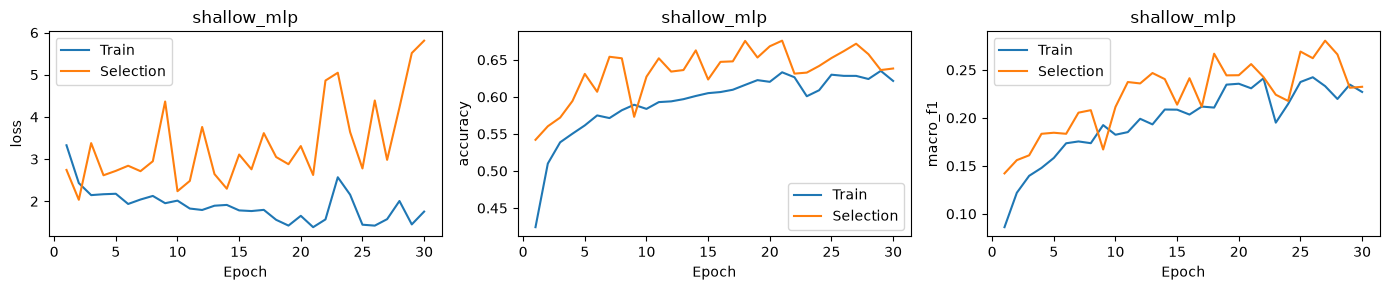

In [23]:
loader = loaders['articleType']['selection']
for method in ['shallow_mlp']:
    model = models['articleType'][method]
    probabilities = np.vstack([tf.nn.softmax(model(loader[i][0], training=False)).numpy() for i in range(len(loader))])
    predictions = probabilities.argmax(axis=1)
    print('articleType', method)
    display(pd.Series({'selection_accuracy': accuracy_score(loader.targets, predictions), 'selection_macro_f1': f1_score(loader.targets, predictions, average='macro', labels=np.unique(loader.targets), zero_division=0)}))
    per_class = classification_report(loader.targets, predictions, labels=np.arange(len(labels_by_target['articleType'])), target_names=labels_by_target['articleType'], output_dict=True, zero_division=0)
    display(pd.DataFrame(per_class).T)
    pd.DataFrame(per_class).T.to_csv(RESULTS / f"{stem_for('articleType')}_{method}_selection_per_class.csv")
    history = histories['articleType'][method]
    fig, axes = plt.subplots(1, 3, figsize=(14, 3))
    for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
        ax.plot(np.arange(1, len(history) + 1), history[metric], label='Train')
        ax.plot(np.arange(1, len(history) + 1), history[f'val_{metric}'], label='Selection')
        ax.set(xlabel='Epoch', ylabel=metric, title=method)
        ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES / f"{stem_for('articleType')}_{method}_learning_curves.png", dpi=160)
    plt.show()

#### 5.1.5. Evaluation Analysis

**Article type.** The selected shallow mlp configuration, `shallow_mlp_lower_lr`, achieves **74.21% selection accuracy and 0.4432 macro-F1**, using 9,469,308 parameters. The original configuration scored 67.17% accuracy and 0.2805 macro-F1; tuning changes macro-F1 by +0.1627. The restored best epoch is 11 of 15; its recorded training-minus-selection accuracy difference is +1.62 percentage points. Training uses dropout and augmentation, so this is a learning-curve diagnostic rather than a like-for-like inference gap.

The most frequent selection class, **Tshirts**, has 512 examples and recall 89.45%. Weak-recall examples include **Dupatta** (0.00% recall, n=6); **Messenger Bag** (0.00% recall, n=5); **Sports Sandals** (0.00% recall, n=5). Macro-F1 averages over the 97 classes present in selection, rather than assuming all output classes are represented. Rare product categories have too few selection examples for stable class-wise estimates. Flattened MLPs struggle to cover the long tail; CNN spatial features improve category recognition substantially, but are not reliable for every output class.

![Article type shallow_mlp learning curves](../figures/article_type_shallow_mlp_lower_lr_learning_curves.png)


### 5.2. Deeper MLP


The deeper MLP processes the same flattened RGB input through three hidden layers. ReLU activations allow successive nonlinear transformations, while dropout reduces reliance on individual activations. Compare its validation metrics and learning-curve gap with the shallow baseline before concluding that depth is useful.


#### 5.2.1. Model Architecture

Flatten the image and use three hidden layers to test whether additional nonlinear transformations improve generalization. ReLU provides nonlinearity; dropout reduces reliance on individual activations. The output is logits, with one value per class.


In [24]:
keras.utils.set_random_seed(SEED)
layers = [keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)), keras.layers.RandomFlip('horizontal'), keras.layers.Flatten()]
for width in [256, 128, 64]:
    layers.extend([keras.layers.Dense(width, activation='relu'), keras.layers.Dropout(0.2)])
layers.extend([keras.layers.Dense(len(labels_by_target['articleType'])), ModelMetadata(name='metadata')])
models['articleType']['deeper_mlp'] = keras.Sequential(layers, name='deeper_mlp')
models['articleType']['deeper_mlp'].summary()

Model: "deeper_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_2 (RandomFlip)      │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 124)            │         8,060 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ metadata (ModelMetadata)        │ (None, 124)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,486,652 (36.19 MB)

 Trainable params: 9,486,652 (36.19 MB)

 Non-trainable params: 0 (0.00 B)

#### 5.2.2. Compile the Model

Adam starts at 0.001. Sparse cross-entropy accepts integer labels and logits; accuracy and macro-F1 are recorded for both training and selection data.


In [25]:
model = models['articleType']['deeper_mlp']
model.compile(optimizer=keras.optimizers.Adam(0.001), loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy'), SupportedMacroF1(len(labels_by_target['articleType']))])

#### 5.2.3. Train the Model

Stop after seven epochs without improved selection macro-F1 and restore the best weights. Reset batch order so candidates start from the same seeded ordering. This cell trains from scratch when rerun.


In [26]:
loaders['articleType']['train'].reset()
callback = keras.callbacks.EarlyStopping(monitor='val_macro_f1', mode='max', patience=7, restore_best_weights=True)
fitted = models['articleType']['deeper_mlp'].fit(loaders['articleType']['train'], validation_data=loaders['articleType']['selection'], epochs=MAX_EPOCHS, callbacks=[callback], shuffle=False, verbose=2)
histories['articleType']['deeper_mlp'] = pd.DataFrame(fitted.history)
display(histories['articleType']['deeper_mlp'].tail())

Epoch 1/30
423/423 - 12s - 29ms/step - accuracy: 0.3546 - loss: 2.8472 - macro_f1: 0.0622 - val_accuracy: 0.5210 - val_loss: 1.7409 - val_macro_f1: 0.1246
Epoch 2/30
423/423 - 11s - 27ms/step - accuracy: 0.4991 - loss: 1.8696 - macro_f1: 0.1041 - val_accuracy: 0.5800 - val_loss: 1.5099 - val_macro_f1: 0.1566
Epoch 3/30
423/423 - 11s - 27ms/step - accuracy: 0.5431 - loss: 1.6478 - macro_f1: 0.1227 - val_accuracy: 0.6166 - val_loss: 1.3798 - val_macro_f1: 0.1792
Epoch 4/30
423/423 - 12s - 27ms/step - accuracy: 0.5698 - loss: 1.5325 - macro_f1: 0.1396 - val_accuracy: 0.6197 - val_loss: 1.3499 - val_macro_f1: 0.1973
Epoch 5/30
423/423 - 12s - 28ms/step - accuracy: 0.5912 - loss: 1.4559 - macro_f1: 0.1509 - val_accuracy: 0.6352 - val_loss: 1.2611 - val_macro_f1: 0.2026
Epoch 6/30
423/423 - 12s - 29ms/step - accuracy: 0.6074 - loss: 1.3954 - macro_f1: 0.1615 - val_accuracy: 0.6459 - val_loss: 1.2127 - val_macro_f1: 0.2043
Epoch 7/30
423/423 - 13s - 30ms/step - accuracy: 0.6147 - loss: 1.3436

,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1
18,0.662822,1.155732,0.203221,0.690345,1.078258,0.264425
19,0.666112,1.134315,0.210075,0.680690,1.110584,0.272139
20,0.664929,1.142532,0.211707,0.697931,1.081789,0.266125
21,0.665521,1.148533,0.208609,0.674138,1.100471,0.266353
22,0.671879,1.105124,0.217446,0.681035,1.100453,0.256522


#### 5.2.4. Evaluation and Performance Metrics

Evaluate restored weights on the selection partition. Report accuracy, macro-F1 and per-class errors, then inspect the learning curves. These are validation diagnostics; selected-model internal-test evaluation remains later.


articleType deeper_mlp


selection_accuracy    0.701379
selection_macro_f1    0.285285
dtype: float64

,precision,recall,f1-score,support
Accessory Gift Set,1.000000,0.833333,0.909091,12.000000
Baby Dolls,0.000000,0.000000,0.000000,0.000000
Backpacks,0.803571,0.833333,0.818182,54.000000
Bangle,1.000000,0.153846,0.266667,13.000000
Basketballs,0.000000,0.000000,0.000000,3.000000
...,...,...,...,...
Water Bottle,0.000000,0.000000,0.000000,1.000000
Wristbands,0.000000,0.000000,0.000000,0.000000
accuracy,0.701379,0.701379,0.701379,0.701379
macro avg,0.248449,0.240459,0.223166,2900.000000


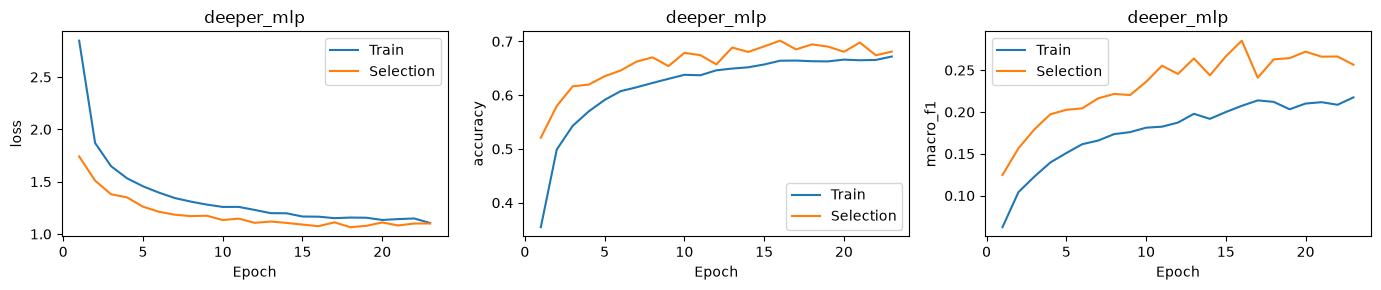

In [27]:
loader = loaders['articleType']['selection']
for method in ['deeper_mlp']:
    model = models['articleType'][method]
    probabilities = np.vstack([tf.nn.softmax(model(loader[i][0], training=False)).numpy() for i in range(len(loader))])
    predictions = probabilities.argmax(axis=1)
    print('articleType', method)
    display(pd.Series({'selection_accuracy': accuracy_score(loader.targets, predictions), 'selection_macro_f1': f1_score(loader.targets, predictions, average='macro', labels=np.unique(loader.targets), zero_division=0)}))
    per_class = classification_report(loader.targets, predictions, labels=np.arange(len(labels_by_target['articleType'])), target_names=labels_by_target['articleType'], output_dict=True, zero_division=0)
    display(pd.DataFrame(per_class).T)
    pd.DataFrame(per_class).T.to_csv(RESULTS / f"{stem_for('articleType')}_{method}_selection_per_class.csv")
    history = histories['articleType'][method]
    fig, axes = plt.subplots(1, 3, figsize=(14, 3))
    for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
        ax.plot(np.arange(1, len(history) + 1), history[metric], label='Train')
        ax.plot(np.arange(1, len(history) + 1), history[f'val_{metric}'], label='Selection')
        ax.set(xlabel='Epoch', ylabel=metric, title=method)
        ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES / f"{stem_for('articleType')}_{method}_learning_curves.png", dpi=160)
    plt.show()

#### 5.2.5. Evaluation Analysis

**Article type.** The selected deeper mlp configuration, `deeper_mlp_lower_lr`, achieves **71.86% selection accuracy and 0.3160 macro-F1**, using 9,486,652 parameters. The original configuration scored 70.14% accuracy and 0.2853 macro-F1; tuning changes macro-F1 by +0.0307. Compared with the selected shallow baseline, the macro-F1 difference is -0.1272, so extra dense depth must be judged by measured generalization rather than layer count. The restored best epoch is 14 of 18; its recorded training-minus-selection accuracy difference is -2.87 percentage points. Training uses dropout and augmentation, so this is a learning-curve diagnostic rather than a like-for-like inference gap.

The most frequent selection class, **Tshirts**, has 512 examples and recall 83.01%. Weak-recall examples include **Flats** (0.00% recall, n=35); **Sweaters** (0.00% recall, n=15); **Duffel Bag** (0.00% recall, n=11). Macro-F1 averages over the 97 classes present in selection, rather than assuming all output classes are represented. Rare product categories have too few selection examples for stable class-wise estimates. Flattened MLPs struggle to cover the long tail; CNN spatial features improve category recognition substantially, but are not reliable for every output class.

![Article type deeper_mlp learning curves](../figures/article_type_deeper_mlp_lower_lr_learning_curves.png)


### 5.3. Convolutional Neural Network (CNN)


The CNN learns local patterns through convolutions and progressively reduces spatial resolution through pooling. Three-block and four-block variants test model capacity, while the scheduled three-block variant isolates the effect of learning-rate reduction. All three remain one CNN family in the main comparison table.


#### 5.3.1. Model Architecture

Convolutions learn local spatial patterns, unlike the flattened MLP inputs. Compare three blocks, the same architecture with a learning-rate schedule, and a four-block variant. Batch normalization stabilizes activations; pooling reduces spatial size. All variants end with a 2 ? 2 pooled grid and a dense head.


In [28]:
CNN_CONFIGS = {'cnn_ordinary': ((32, 64, 128), 128, False), 'cnn_scheduled': ((32, 64, 128), 128, True), 'cnn_four_blocks_scheduled': ((32, 64, 128, 256), 256, True)}
for method, (channels, hidden, scheduled) in CNN_CONFIGS.items():
    keras.utils.set_random_seed(SEED)
    layers = [keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)), keras.layers.RandomFlip('horizontal')]
    for width in channels:
        layers.extend([keras.layers.Conv2D(width, 3, padding='same'), keras.layers.BatchNormalization(), keras.layers.Activation('relu'), keras.layers.MaxPooling2D(2)])
    h, w = (IMAGE_SIZE[1] // 2 ** len(channels), IMAGE_SIZE[0] // 2 ** len(channels))
    layers.extend([keras.layers.AveragePooling2D((h // 2, w // 2)), keras.layers.Flatten(), keras.layers.Dense(hidden, activation='relu'), keras.layers.Dropout(0.2), keras.layers.Dense(len(labels_by_target['articleType'])), ModelMetadata(name='metadata')])
    models['articleType'][method] = keras.Sequential(layers, name=method)
    models['articleType'][method].summary()

Model: "cnn_ordinary"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_3 (RandomFlip)      │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 96, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 96, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 96, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 2, 2, 128)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 124)            │        15,996 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ metadata (ModelMetadata)        │ (None, 124)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 175,804 (686.73 KB)

 Trainable params: 175,356 (684.98 KB)

 Non-trainable params: 448 (1.75 KB)

...

Model: "cnn_four_blocks_scheduled"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_5 (RandomFlip)      │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 96, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128, 96, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 128, 96, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 64, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 32, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 16, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 2, 2, 256)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 124)            │        31,868 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 684,604 (2.61 MB)

 Trainable params: 683,644 (2.61 MB)

 Non-trainable params: 960 (3.75 KB)

#### 5.3.2. Compile the CNN Models

Keep optimizer, loss and metrics the same as the MLPs so the comparison tests architecture and the declared schedule.


In [29]:
for method in CNN_CONFIGS:
    models['articleType'][method].compile(optimizer=keras.optimizers.Adam(0.001), loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy'), SupportedMacroF1(len(labels_by_target['articleType']))])

#### 5.3.3. Train and Tune the CNN Models

Scheduled variants halve the learning rate after two epochs without improvement. All variants stop after seven stale epochs. Selection data controls these decisions; test data is not read here.


In [30]:
for method, (_, _, scheduled) in CNN_CONFIGS.items():
    loaders['articleType']['train'].reset()
    callbacks = []
    if scheduled:
        callbacks.append(keras.callbacks.ReduceLROnPlateau(monitor='val_macro_f1', mode='max', factor=0.5, patience=2))
    callbacks.append(keras.callbacks.EarlyStopping(monitor='val_macro_f1', mode='max', patience=7, restore_best_weights=True))
    fitted = models['articleType'][method].fit(loaders['articleType']['train'], validation_data=loaders['articleType']['selection'], epochs=MAX_EPOCHS, callbacks=callbacks, shuffle=False, verbose=2)
    histories['articleType'][method] = pd.DataFrame(fitted.history)
    display(histories['articleType'][method].tail())

Epoch 1/30


2026-09-11 00:24:20.727816: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92501


423/423 - 27s - 65ms/step - accuracy: 0.4709 - loss: 2.0986 - macro_f1: 0.0912 - val_accuracy: 0.5259 - val_loss: 1.8561 - val_macro_f1: 0.1287
Epoch 2/30
423/423 - 25s - 58ms/step - accuracy: 0.6413 - loss: 1.3048 - macro_f1: 0.1777 - val_accuracy: 0.6441 - val_loss: 1.3145 - val_macro_f1: 0.2189
Epoch 3/30
423/423 - 25s - 58ms/step - accuracy: 0.6868 - loss: 1.0832 - macro_f1: 0.2221 - val_accuracy: 0.6531 - val_loss: 1.1892 - val_macro_f1: 0.2198
Epoch 4/30
423/423 - 25s - 59ms/step - accuracy: 0.7146 - loss: 0.9643 - macro_f1: 0.2589 - val_accuracy: 0.6803 - val_loss: 1.0397 - val_macro_f1: 0.2762
Epoch 5/30
423/423 - 26s - 61ms/step - accuracy: 0.7326 - loss: 0.8917 - macro_f1: 0.2993 - val_accuracy: 0.6993 - val_loss: 1.0250 - val_macro_f1: 0.2943
Epoch 6/30
423/423 - 25s - 60ms/step - accuracy: 0.7484 - loss: 0.8351 - macro_f1: 0.3157 - val_accuracy: 0.7031 - val_loss: 0.9772 - val_macro_f1: 0.3148
Epoch 7/30
423/423 - 26s - 61ms/step - accuracy: 0.7603 - loss: 0.7923 - macro_f1

,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1
17,0.813242,0.574737,0.507965,0.767931,0.781653,0.436120
18,0.814683,0.563136,0.518018,0.782414,0.806706,0.443333
19,0.819674,0.555750,0.547370,0.784483,0.733027,0.467605
20,0.821855,0.542518,0.549626,0.742414,0.914260,0.425986
21,0.824886,0.530818,0.558773,0.741035,0.928966,0.367388


Epoch 1/30
423/423 - 27s - 63ms/step - accuracy: 0.4709 - loss: 2.0986 - macro_f1: 0.0912 - val_accuracy: 0.5259 - val_loss: 1.8561 - val_macro_f1: 0.1287 - learning_rate: 0.0010
Epoch 2/30
423/423 - 25s - 59ms/step - accuracy: 0.6413 - loss: 1.3048 - macro_f1: 0.1777 - val_accuracy: 0.6441 - val_loss: 1.3145 - val_macro_f1: 0.2189 - learning_rate: 0.0010
Epoch 3/30
423/423 - 25s - 60ms/step - accuracy: 0.6868 - loss: 1.0832 - macro_f1: 0.2221 - val_accuracy: 0.6531 - val_loss: 1.1892 - val_macro_f1: 0.2198 - learning_rate: 0.0010
Epoch 4/30
423/423 - 25s - 60ms/step - accuracy: 0.7146 - loss: 0.9643 - macro_f1: 0.2589 - val_accuracy: 0.6803 - val_loss: 1.0397 - val_macro_f1: 0.2762 - learning_rate: 0.0010
Epoch 5/30
423/423 - 25s - 59ms/step - accuracy: 0.7326 - loss: 0.8917 - macro_f1: 0.2993 - val_accuracy: 0.6993 - val_loss: 1.0250 - val_macro_f1: 0.2943 - learning_rate: 0.0010
Epoch 6/30
423/423 - 25s - 59ms/step - accuracy: 0.7484 - loss: 0.8351 - macro_f1: 0.3157 - val_accuracy:

,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1,learning_rate
25,0.849802,0.448151,0.633064,0.821724,0.620162,0.548213,0.00025
26,0.852760,0.441498,0.630340,0.829310,0.592465,0.577082,0.00025
27,0.852871,0.440898,0.634924,0.824138,0.596773,0.535149,0.00025
28,0.855052,0.434243,0.631766,0.833448,0.586918,0.591687,0.00025
29,0.856234,0.433135,0.617696,0.829655,0.577536,0.552852,0.00025


Epoch 1/30
423/423 - 28s - 67ms/step - accuracy: 0.5627 - loss: 1.7041 - macro_f1: 0.1335 - val_accuracy: 0.5534 - val_loss: 1.6694 - val_macro_f1: 0.1755 - learning_rate: 0.0010
Epoch 2/30
423/423 - 27s - 65ms/step - accuracy: 0.7107 - loss: 1.0032 - macro_f1: 0.2346 - val_accuracy: 0.7124 - val_loss: 0.9867 - val_macro_f1: 0.2925 - learning_rate: 0.0010
Epoch 3/30
423/423 - 27s - 64ms/step - accuracy: 0.7509 - loss: 0.8295 - macro_f1: 0.2910 - val_accuracy: 0.7617 - val_loss: 0.7968 - val_macro_f1: 0.3633 - learning_rate: 0.0010
Epoch 4/30
423/423 - 27s - 64ms/step - accuracy: 0.7762 - loss: 0.7272 - macro_f1: 0.3553 - val_accuracy: 0.7245 - val_loss: 0.9143 - val_macro_f1: 0.3091 - learning_rate: 0.0010
Epoch 5/30
423/423 - 28s - 66ms/step - accuracy: 0.7942 - loss: 0.6592 - macro_f1: 0.3970 - val_accuracy: 0.7741 - val_loss: 0.8027 - val_macro_f1: 0.3993 - learning_rate: 0.0010
Epoch 6/30
423/423 - 27s - 64ms/step - accuracy: 0.8058 - loss: 0.6099 - macro_f1: 0.4298 - val_accuracy:

,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1,learning_rate
25,0.951943,0.143111,0.884679,0.869310,0.525676,0.646515,0.000125
26,0.955455,0.135812,0.896061,0.867241,0.509331,0.628895,0.000125
27,0.956748,0.131039,0.894522,0.871035,0.529755,0.666445,0.000125
28,0.957118,0.127095,0.889586,0.868966,0.529161,0.644668,0.000125
29,0.961517,0.121082,0.897994,0.870345,0.532469,0.627162,0.000125


#### 5.3.4. Evaluation and Performance Metrics

Evaluate restored weights on the selection partition. Report accuracy, macro-F1 and per-class errors, then inspect the learning curves. These are validation diagnostics; selected-model internal-test evaluation remains later.


articleType cnn_ordinary


selection_accuracy    0.780345
selection_macro_f1    0.472314
dtype: float64

,precision,recall,f1-score,support
Accessory Gift Set,1.000000,1.000000,1.000000,12.000000
Baby Dolls,0.000000,0.000000,0.000000,0.000000
Backpacks,0.859649,0.907407,0.882883,54.000000
Bangle,1.000000,0.076923,0.142857,13.000000
Basketballs,1.000000,1.000000,1.000000,3.000000
...,...,...,...,...
Water Bottle,0.000000,0.000000,0.000000,1.000000
Wristbands,0.000000,0.000000,0.000000,0.000000
accuracy,0.780345,0.780345,0.780345,0.780345
macro avg,0.430979,0.372699,0.369472,2900.000000


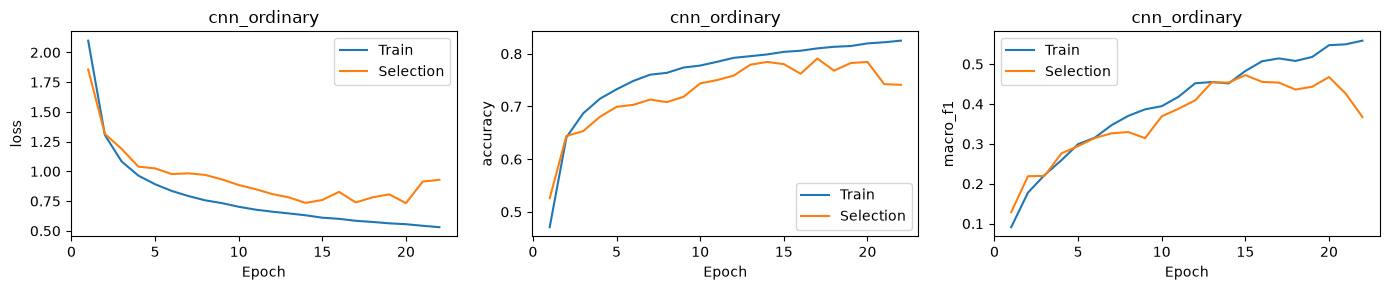

articleType cnn_scheduled


selection_accuracy    0.833448
selection_macro_f1    0.591687
dtype: float64

,precision,recall,f1-score,support
Accessory Gift Set,1.000000,1.000000,1.000000,12.000000
Baby Dolls,0.000000,0.000000,0.000000,0.000000
Backpacks,0.940000,0.870370,0.903846,54.000000
Bangle,0.500000,0.153846,0.235294,13.000000
Basketballs,1.000000,1.000000,1.000000,3.000000
...,...,...,...,...
Water Bottle,0.000000,0.000000,0.000000,1.000000
Wristbands,0.000000,0.000000,0.000000,0.000000
accuracy,0.833448,0.833448,0.833448,0.833448
macro avg,0.503009,0.461021,0.462852,2900.000000


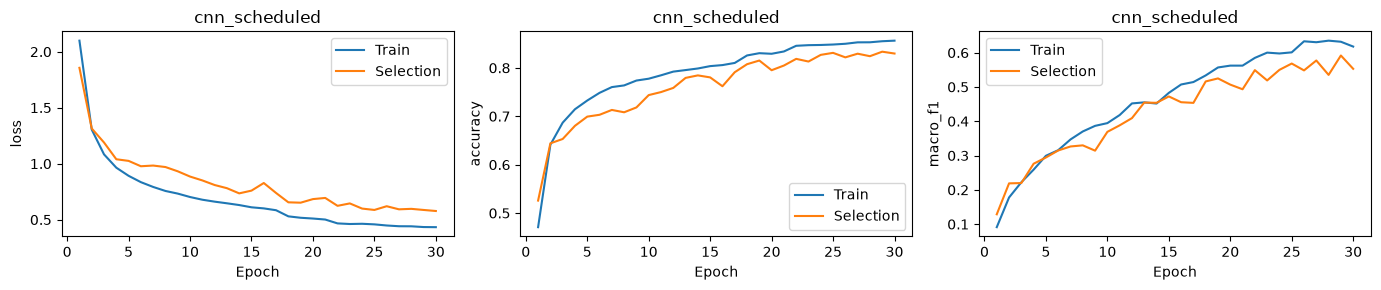

articleType cnn_four_blocks_scheduled


selection_accuracy    0.871034
selection_macro_f1    0.666445
dtype: float64

,precision,recall,f1-score,support
Accessory Gift Set,1.000000,1.000000,1.000000,12.000000
Baby Dolls,0.000000,0.000000,0.000000,0.000000
Backpacks,0.961538,0.925926,0.943396,54.000000
Bangle,0.500000,0.153846,0.235294,13.000000
Basketballs,1.000000,0.333333,0.500000,3.000000
...,...,...,...,...
Water Bottle,1.000000,1.000000,1.000000,1.000000
Wristbands,0.000000,0.000000,0.000000,0.000000
accuracy,0.871034,0.871034,0.871034,0.871034
macro avg,0.543383,0.526087,0.521332,2900.000000


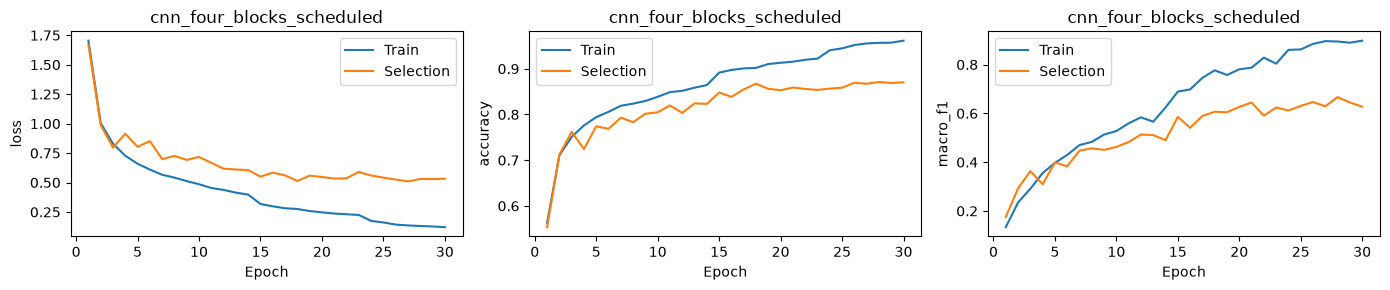

In [31]:
loader = loaders['articleType']['selection']
for method in list(CNN_CONFIGS):
    model = models['articleType'][method]
    probabilities = np.vstack([tf.nn.softmax(model(loader[i][0], training=False)).numpy() for i in range(len(loader))])
    predictions = probabilities.argmax(axis=1)
    print('articleType', method)
    display(pd.Series({'selection_accuracy': accuracy_score(loader.targets, predictions), 'selection_macro_f1': f1_score(loader.targets, predictions, average='macro', labels=np.unique(loader.targets), zero_division=0)}))
    per_class = classification_report(loader.targets, predictions, labels=np.arange(len(labels_by_target['articleType'])), target_names=labels_by_target['articleType'], output_dict=True, zero_division=0)
    display(pd.DataFrame(per_class).T)
    pd.DataFrame(per_class).T.to_csv(RESULTS / f"{stem_for('articleType')}_{method}_selection_per_class.csv")
    history = histories['articleType'][method]
    fig, axes = plt.subplots(1, 3, figsize=(14, 3))
    for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
        ax.plot(np.arange(1, len(history) + 1), history[metric], label='Train')
        ax.plot(np.arange(1, len(history) + 1), history[f'val_{metric}'], label='Selection')
        ax.set(xlabel='Epoch', ylabel=metric, title=method)
        ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES / f"{stem_for('articleType')}_{method}_learning_curves.png", dpi=160)
    plt.show()

#### 5.3.5. Evaluation Analysis

**Article type.** The selected cnn configuration, `cnn_continue_weighted`, achieves **87.00% selection accuracy and 0.6954 macro-F1**, using 684,604 parameters. The original configuration scored 87.10% accuracy and 0.6664 macro-F1; tuning changes macro-F1 by +0.0290. The macro-F1 gain over the selected deeper MLP is +0.3794. The CNN learns spatial patterns with far fewer parameters than the flattened MLPs. The restored best continuation epoch is 6 of 8; its recorded training-minus-selection accuracy difference is +9.34 percentage points. Training uses dropout and augmentation, so this is a learning-curve diagnostic rather than a like-for-like inference gap.

The most frequent selection class, **Tshirts**, has 512 examples and recall 92.97%. Weak-recall examples include **Messenger Bag** (0.00% recall, n=5); **Bracelet** (0.00% recall, n=4); **Clothing Set** (0.00% recall, n=2). Macro-F1 averages over the 97 classes present in selection, rather than assuming all output classes are represented. Rare product categories have too few selection examples for stable class-wise estimates. Flattened MLPs struggle to cover the long tail; CNN spatial features improve category recognition substantially, but are not reliable for every output class. There are 13 selection-supported classes with zero recall. Among classes with at least ten selection examples, weak recall includes Bangle (15.38%, n=13); Capris (35.71%, n=14); Jackets (45.45%, n=22).

![Article type cnn learning curves](../figures/article_type_cnn_continue_weighted_learning_curves.png)


#### 5.3.6. Target-specific parameter tuning

The completed first run motivates lower learning rates for the unstable MLPs and a short CNN continuation with and without class weighting. These are additional candidates, not assumed improvements. Only training counts determine weights; selection macro-F1 chooses the winner. Calibration, policy and internal-test images are excluded from fitting.

Both CNN candidates start from identical selected CNN weights. Their shared learning rate, dropout, seed and epoch budget isolate the effect of class weights. Each MLP keeps its original architecture and uses a lower learning rate for up to 20 epochs. CNN continuation uses up to 8 additional epochs; its history records additional epochs only.

**Execution record:** This tuning round reused the four exported CNNs after the previous kernel shut down. Original MLP/CNN fitting cells were not rerun. Their measured histories and experiment rows were loaded for comparison; only the added candidates were fitted. For a future fresh Run All, `RESUME_SAVED_RESULTS=False` prevents mixing previous experiment rows into the new run. To resume intentionally, enable it only with matching data, splits, label order and preprocessing, and load the corresponding history CSVs before comparison.


**articleType: configure candidates and training-only weights.** Normalize square-root inverse-frequency weights to mean one over training examples, then cap them at 4 to limit the influence of extremely rare labels. Validation metrics remain unweighted.


In [11]:
PARAMETER_CONFIGS_articleType = {
    'shallow_mlp_lower_lr': dict(family='shallow_mlp', learning_rate=1e-4, epochs=20, weighted=False),
    'deeper_mlp_lower_lr': dict(family='deeper_mlp', learning_rate=3e-4, epochs=20, weighted=False),
    'cnn_continue': dict(family='cnn', learning_rate=3e-05, epochs=8, weighted=False),
    'cnn_continue_weighted': dict(family='cnn', learning_rate=3e-05, epochs=8, weighted=True),
}
counts = np.bincount(loaders['articleType']['train'].targets, minlength=len(labels_by_target['articleType']))
assert (counts > 0).all()
weights = np.sqrt(counts.sum() / (len(counts) * counts))
weights = np.clip(weights / np.average(weights, weights=counts), 0.25, 4)
class_weights_articleType = {i: float(value) for i, value in enumerate(weights)}
if 'cnn_four_blocks_scheduled' in models['articleType']:
    tuning_source_articleType = models['articleType']['cnn_four_blocks_scheduled']
else:
    tuning_source_articleType = keras.models.load_model(OUTPUT / f"{stem_for('articleType')}_model.keras", compile=False)
    saved_metadata = tuning_source_articleType.get_layer('metadata').metadata
    assert saved_metadata['target'] == 'articleType' and saved_metadata['labels'] == labels_by_target['articleType']
    assert saved_metadata['model_type'].startswith('cnn')
    assert saved_metadata['image_size'] == list(IMAGE_SIZE)
    np.testing.assert_allclose(saved_metadata['mean'], normalisation['mean'])
    np.testing.assert_allclose(saved_metadata['std'], normalisation['std'])
    models['articleType'][saved_metadata['model_type']] = tuning_source_articleType
for method, config in PARAMETER_CONFIGS_articleType.items():
    keras.utils.set_random_seed(SEED)
    if config['family'] == 'cnn':
        candidate = keras.models.clone_model(tuning_source_articleType)
        candidate.set_weights(tuning_source_articleType.get_weights())
        candidate.get_layer('metadata').metadata = {}
    else:
        widths = [256] if config['family'] == 'shallow_mlp' else [256, 128, 64]
        layers = [keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)), keras.layers.RandomFlip('horizontal'), keras.layers.Flatten()]
        for width in widths:
            layers.extend([keras.layers.Dense(width, activation='relu'), keras.layers.Dropout(0.2)])
        layers.extend([keras.layers.Dense(len(labels_by_target['articleType'])), ModelMetadata(name='metadata')])
        candidate = keras.Sequential(layers, name=method)
    candidate.compile(optimizer=keras.optimizers.Adam(config['learning_rate']), loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=[keras.metrics.SparseCategoricalAccuracy(name='accuracy'), SupportedMacroF1(len(labels_by_target['articleType']))])
    models['articleType'][method] = candidate
pd.DataFrame(PARAMETER_CONFIGS_articleType).T.to_csv(RESULTS / f"{stem_for('articleType')}_parameter_configs.csv")
display(pd.DataFrame(PARAMETER_CONFIGS_articleType).T)


I0000 00:00:1789096971.473276  211830 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9709 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


,family,learning_rate,epochs,weighted
shallow_mlp_lower_lr,shallow_mlp,0.0001,20,False
deeper_mlp_lower_lr,deeper_mlp,0.0003,20,False
cnn_continue,cnn,0.00003,8,False
cnn_continue_weighted,cnn,0.00003,8,True


**articleType: fit the additional candidates.** Early stopping restores the best selection macro-F1. Paired CNN runs reset random state and batch ordering. Class weights affect training loss only ([Keras training API](https://keras.io/api/models/model_training_apis/)).


In [12]:
for method, config in PARAMETER_CONFIGS_articleType.items():
    keras.utils.set_random_seed(SEED)
    loaders['articleType']['train'].reset()
    callbacks = [keras.callbacks.EarlyStopping(monitor='val_macro_f1', mode='max', patience=4, restore_best_weights=True)]
    print('articleType', method, flush=True)
    fitted = models['articleType'][method].fit(loaders['articleType']['train'], validation_data=loaders['articleType']['selection'], epochs=config['epochs'], callbacks=callbacks, class_weight=class_weights_articleType if config['weighted'] else None, shuffle=False, verbose=2)
    histories['articleType'][method] = pd.DataFrame(fitted.history)
    histories['articleType'][method].to_csv(RESULTS / f"{stem_for('articleType')}_{method}_history.csv", index=False)
    display(histories['articleType'][method].tail())


articleType shallow_mlp_lower_lr


Epoch 1/20


423/423 - 12s - 29ms/step - accuracy: 0.5507 - loss: 1.8796 - macro_f1: 0.1490 - val_accuracy: 0.6455 - val_loss: 1.4375 - val_macro_f1: 0.2277


Epoch 2/20


423/423 - 11s - 25ms/step - accuracy: 0.6427 - loss: 1.3946 - macro_f1: 0.2097 - val_accuracy: 0.6662 - val_loss: 1.2696 - val_macro_f1: 0.2343


...

Epoch 7/8


423/423 - 25s - 60ms/step - accuracy: 0.9657 - loss: 0.1313 - macro_f1: 0.9339 - val_accuracy: 0.8710 - val_loss: 0.5410 - val_macro_f1: 0.6834


Epoch 8/8


423/423 - 26s - 60ms/step - accuracy: 0.9674 - loss: 0.1278 - macro_f1: 0.9321 - val_accuracy: 0.8707 - val_loss: 0.5428 - val_macro_f1: 0.6775


,accuracy,loss,macro_f1,val_accuracy,val_loss,val_macro_f1
3,0.966766,0.134523,0.943041,0.870000,0.538511,0.689896
4,0.963809,0.138014,0.938313,0.869310,0.536109,0.684034
5,0.963439,0.132909,0.916387,0.870000,0.541208,0.695401
6,0.965657,0.131293,0.933928,0.871035,0.540997,0.683386
7,0.967432,0.127772,0.932064,0.870690,0.542803,0.677488


**articleType: evaluate on selection images.** The final comparison keeps the best candidate within each family. Rare-class recall accompanies overall scores; continuation is retained only if it wins the declared ranking.


In [13]:
loader = loaders['articleType']['selection']
for method in PARAMETER_CONFIGS_articleType:
    probabilities = np.vstack([tf.nn.softmax(models['articleType'][method](loader[i][0], training=False)).numpy() for i in range(len(loader))])
    predictions = probabilities.argmax(1)
    per_class = classification_report(loader.targets, predictions, labels=np.arange(len(labels_by_target['articleType'])), target_names=labels_by_target['articleType'], output_dict=True, zero_division=0)
    pd.DataFrame(per_class).T.to_csv(RESULTS / f"{stem_for('articleType')}_{method}_selection_per_class.csv")
    display(pd.Series(dict(method=method, accuracy=accuracy_score(loader.targets, predictions), macro_f1=f1_score(loader.targets, predictions, labels=np.unique(loader.targets), average='macro', zero_division=0))))


method      shallow_mlp_lower_lr
accuracy                0.742069
macro_f1                0.443202
dtype: object

method      deeper_mlp_lower_lr
accuracy               0.718621
macro_f1                0.31603
dtype: object

method      cnn_continue
accuracy        0.870345
macro_f1        0.664806
dtype: object

method      cnn_continue_weighted
accuracy                     0.87
macro_f1                 0.695401
dtype: object

### 5.4. Model Comparison

Choose the best configuration within each of the three families using selection macro-F1, then accuracy, then fewer parameters. Original runs and the additional parameter experiments are compared on the same selection partition. The three-row table reports family winners; the experiments CSV retains candidate-level evidence.


In [8]:
def supported_macro_f1(truth, predictions) -> float:
    """Macro-average over labels present in the ground-truth partition."""
    return float(f1_score(
        truth, predictions, labels=np.unique(truth), average="macro", zero_division=0
    ))

def expected_calibration_error(
    truth: np.ndarray,
    probabilities: np.ndarray,
    bins: int = 10,
) -> float:
    """Compute top-label expected calibration error."""
    truth = np.asarray(truth)
    probabilities = np.asarray(probabilities)
    confidence = probabilities.max(axis=1)
    correct = probabilities.argmax(axis=1) == truth
    edges = np.linspace(0.0, 1.0, bins + 1)
    total = len(truth)
    error = 0.0
    for lower, upper in zip(edges[:-1], edges[1:], strict=True):
        selected = (confidence > lower) & (confidence <= upper)
        if selected.any():
            error += selected.sum() / total * abs(
                float(correct[selected].mean()) - float(confidence[selected].mean())
            )
    return float(error)

def ranked(table):
    """Predeclared: macro F1, then accuracy, then fewer parameters."""
    return table.sort_values(['validation_macro_f1', 'validation_accuracy', 'complexity_parameters'],
                             ascending=[False, False, True], kind='stable')

In [15]:
comparisons, tuning, winners, checkpoints = ({}, {}, {}, {})
rows = []
loader = loaders['articleType']['selection']
for method, model in models['articleType'].items():
    probabilities = np.vstack([tf.nn.softmax(model(loader[i][0], training=False)).numpy() for i in range(len(loader))])
    rows.append(dict(method=method, validation_accuracy=accuracy_score(loader.targets, probabilities.argmax(1)), validation_macro_f1=supported_macro_f1(loader.targets, probabilities.argmax(1)), validation_ece=expected_calibration_error(loader.targets, probabilities), complexity_parameters=model.count_params(), epochs_run=len(histories['articleType'][method])))
experiments = pd.DataFrame(rows).set_index('method')
# Resume measured candidates whose weights were not exported after kernel shutdown.
previous_path = RESULTS / f"{stem_for('articleType')}_experiments.csv"
if RESUME_SAVED_RESULTS and previous_path.exists():
    previous = pd.read_csv(previous_path, index_col='method')
    experiments = pd.concat([previous.loc[~previous.index.isin(experiments.index)], experiments])
experiments.to_csv(RESULTS / f"{stem_for('articleType')}_experiments.csv")
tuning['articleType'] = experiments.loc[experiments.index.str.startswith('cnn')].copy()
for metric in ['accuracy', 'macro_f1']:
    tuning['articleType'][f'{metric}_change_vs_ordinary'] = tuning['articleType'][f'validation_{metric}'] - tuning['articleType'].loc['cnn_ordinary', f'validation_{metric}']
best_cnn = ranked(tuning['articleType']).index[0]
best_shallow = ranked(experiments.loc[experiments.index.str.startswith('shallow_mlp')]).index[0]
best_deeper = ranked(experiments.loc[experiments.index.str.startswith('deeper_mlp')]).index[0]
table = experiments.loc[[best_shallow, best_deeper, best_cnn]].copy()
table['family'] = ['shallow_mlp', 'deeper_mlp', 'cnn']
winners['articleType'] = ranked(table).index[0]
table['selected'] = table.index == winners['articleType']
comparisons['articleType'] = table
table.to_csv(RESULTS / f"{stem_for('articleType')}_comparison.csv")
tuning['articleType'].to_csv(RESULTS / f"{stem_for('articleType')}_cnn_tuning.csv")
display(table)
display(tuning['articleType'])
assert winners['articleType'] in models['articleType'], 'Winning weights are missing; retrain that candidate before export.'


,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,family,selected
method,,,,,,,
shallow_mlp_lower_lr,0.742069,0.443202,0.026717,9469308,15,shallow_mlp,False
deeper_mlp_lower_lr,0.718621,0.316030,0.042619,9486652,18,deeper_mlp,False
cnn_continue_weighted,0.870000,0.695401,0.040363,684604,8,cnn,True


,validation_accuracy,validation_macro_f1,validation_ece,complexity_parameters,epochs_run,accuracy_change_vs_ordinary,macro_f1_change_vs_ordinary
method,,,,,,,
cnn_ordinary,0.780345,0.472314,0.018076,175804,22,0.000000,0.000000
cnn_scheduled,0.833448,0.591687,0.017734,175804,30,0.053103,0.119373
cnn_four_blocks_scheduled,0.871034,0.666445,0.039313,684604,30,0.090690,0.194131
cnn_continue,0.870345,0.664806,0.050317,684604,8,0.090000,0.192492
cnn_continue_weighted,0.870000,0.695401,0.040363,684604,8,0.089655,0.223086


### 5.5. Learning Curves

Inspect the restored best epoch and later trajectory rather than the final epoch alone. Training enables augmentation and dropout; selection uses inference mode, so a negative training-minus-selection accuracy gap is possible.

The class-weighted CNN uses weighted training loss but unweighted validation loss. Their raw loss gap does not directly measure overfitting. Accuracy and supported-class macro-F1 remain unweighted and are comparable across candidates, subject to the training/inference-mode difference. CNN continuation plots count additional epochs from the shared starting checkpoint.


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for method, history in histories['articleType'].items():
    history = history.copy()
    history.insert(0, 'epoch', np.arange(1, len(history) + 1))
    history.to_csv(RESULTS / f"{stem_for('articleType')}_{method}_history.csv", index=False)
    for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
        ax.plot(history.epoch, history[metric], linestyle='--', alpha=0.6, label=f'{method}: train')
        ax.plot(history.epoch, history[f'val_{metric}'], label=f'{method}: selection')
        ax.set(xlabel='Epoch', ylabel=metric, title='articleType')
axes[-1].legend(fontsize=6)
fig.tight_layout()
fig.savefig(FIGURES / f"{stem_for('articleType')}_learning_curves.png", dpi=160)
plt.show()

/tmp/ipykernel_211830/2407487844.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### 5.6. Model Evaluation & Error Analysis

The following small inference helpers reproduce application preprocessing. Temperature scaling changes confidence, not the predicted class. Calibration is fitted on separate groups, then accepted only if policy-group NLL improves without worsening ECE.


#### 5.6.1. Prepare one inference image

Use the same RGB resizing and training-only normalization as the training batches.


In [9]:
def image_batch(image, image_size, mean, std):
    resized = image.convert("RGB").resize(tuple(image_size), Image.Resampling.BILINEAR)
    array = np.asarray(resized, dtype=np.float32) / 255.0
    array = (array - np.asarray(mean, dtype=np.float32)) / np.asarray(std, dtype=np.float32)
    return array[None, ...]

#### 5.6.2. Rescale confidence

Divide log probabilities by a positive temperature and renormalize.


In [10]:
def temperature_scale(probabilities, temperature=1.0):
    """Rescale confidence without changing the highest-probability class."""
    if not np.isfinite(temperature) or temperature <= 0:
        raise ValueError('Temperature must be finite and positive')
    values = np.asarray(probabilities, dtype=np.float64)
    if values.ndim < 1 or values.shape[-1] == 0 or (not np.isfinite(values).all()) or (values < 0).any():
        raise ValueError('Probabilities must be finite, nonnegative vectors')
    mass = values.sum(axis=-1, keepdims=True)
    if (mass <= 0).any():
        raise ValueError('Probability vectors must have positive mass')
    values = values / mass
    if temperature == 1.0:
        return values
    logits = np.log(np.clip(values, np.finfo(np.float64).tiny, 1.0)) / temperature
    logits -= logits.max(axis=-1, keepdims=True)
    scaled = np.exp(logits)
    return scaled / scaled.sum(axis=-1, keepdims=True)


#### 5.6.3. Notebook prediction interface

Use the same logits, labels and review-policy semantics as the web application. This class performs inference only.


In [11]:
class FashionClassifier:
    def __init__(self, checkpoint_path, device=None):
        checkpoint = checkpoint_path if isinstance(checkpoint_path, dict) else load_checkpoint(checkpoint_path)
        self.device = "/CPU:0" if device == "cpu" else (device if device and str(device).startswith("/") else None)
        self.target, self.labels = checkpoint["target"], list(checkpoint["labels"])
        self.temperature = float(checkpoint.get("temperature", 1.0))
        self.review_policy = checkpoint.get("review_policy")
        self.model_type = checkpoint["model_type"]
        self.model = checkpoint.get("model")
        self.members = None
        if self.model is not None:
            self.mean, self.std = checkpoint["mean"], checkpoint["std"]
            self.image_size = checkpoint["image_size"]
            self.estimator = self.feature_config = None
        else:
            raise ValueError("Classifier has no trained Keras model")

    def predict_batch(self, inputs):
        with tf.device(self.device):
            probabilities = tf.nn.softmax(self.model(inputs, training=False), axis=-1).numpy()
        return temperature_scale(probabilities, self.temperature)

    def predict_probabilities(self, image):
        inputs = image_batch(image, self.image_size, self.mean, self.std)
        return self.predict_batch(inputs)[0]

    def predict(self, image: Image.Image, top_k: int = 3) -> dict:
        if top_k < 1:
            raise ValueError("top_k must be positive")
        probabilities = self.predict_probabilities(image)
        count = min(top_k, len(self.labels))
        indices = np.argsort(probabilities)[::-1][:count]
        ranked = [
            {"label": self.labels[int(index)], "confidence": float(probabilities[index])}
            for index in indices
        ]
        result = {
            "target": self.target,
            "label": ranked[0]["label"],
            "confidence": ranked[0]["confidence"],
            "top_k": ranked,
        }
        if self.review_policy is not None:
            threshold = self.review_policy['threshold']
            result['needs_review'] = threshold is None or ranked[0]['confidence'] < threshold
            result['review_threshold'] = threshold
            result['confidence_calibrated'] = self.temperature != 1.0
            if self.review_policy.get('brightness_stability') and not result['needs_review']:
                stable_label = int(indices[0])
                unstable = any(
                    int(self.predict_probabilities(ImageEnhance.Brightness(image.convert('RGB')).enhance(factor)).argmax()) != stable_label
                    for factor in (0.8, 1.2)
                )
                if unstable:
                    result['needs_review'] = True
                    result['review_reason'] = 'Prediction changes with lighting'
        return result

#### 5.6.4. Evaluate a partition

Compute accuracy, supported-class macro-F1, ECE, NLL and Brier score. Record sampled batch/single-image differences as a diagnostic; large differences or changed predictions warn, while invalid probabilities raise an error.


In [12]:
def evaluate_saved_checkpoint(checkpoint_path, frame, device="cpu", batch_size=64):
    """Re-evaluate a frozen artifact with the application's exact preprocessing.

    This never fits a model or changes its checkpoint. Batching changes only
    execution and may slightly affect floating-point scores; label ordering
    and saved temperature match the web API.
    """
    from sklearn.metrics import log_loss

    if frame.empty:
        raise ValueError("Evaluation requires at least one image")
    predictor = FashionClassifier(checkpoint_path, device=device)
    labels = predictor.labels
    truth = np.asarray([labels.index(label) for label in frame[predictor.target]])
    batches = []
    for start in range(0, len(frame), batch_size):
        inputs = []
        for path in frame.image_path.iloc[start:start + batch_size]:
            with Image.open(path) as source:
                inputs.append(image_batch(source, predictor.image_size, predictor.mean, predictor.std))
        batches.append(predictor.predict_batch(np.concatenate(inputs)))
    probabilities = np.vstack(batches)
    if (probabilities.shape != (len(frame), len(labels))
            or not np.isfinite(probabilities).all()
            or (probabilities < 0).any()
            or not np.allclose(probabilities.sum(axis=1), 1.0, atol=1e-5, rtol=1e-5)):
        raise ValueError("Batch inference returned invalid probabilities")
    predictions = probabilities.argmax(1)
    metrics = {
        "accuracy": float(accuracy_score(truth, predictions)),
        "macro_f1": supported_macro_f1(truth, predictions),
        "ece": expected_calibration_error(truth, probabilities),
        "nll": float(log_loss(truth, probabilities, labels=np.arange(len(labels)))),
        "brier": float(np.mean(np.sum((probabilities - np.eye(len(labels))[truth]) ** 2, axis=1))),
    }
    # Batch and single-image GPU kernels can produce slightly different scores.
    # Sample this difference as a diagnostic, not a requirement for calibration.
    # A 0.001 absolute difference means 0.1 percentage points of probability;
    # it is a warning threshold, not a guarantee of equivalent predictions.
    import warnings

    positions = sorted({0, len(frame) // 2, len(frame) - 1})
    max_absolute_difference = 0.0
    prediction_mismatches = []
    for position in positions:
        with Image.open(frame.image_path.iloc[position]) as source:
            single = np.asarray(predictor.predict_probabilities(source))
        if (single.shape != probabilities[position].shape
                or not np.isfinite(single).all()
                or (single < 0).any()
                or not np.isclose(single.sum(), 1.0, atol=1e-5, rtol=1e-5)):
            raise ValueError("Single-image inference returned invalid probabilities")
        difference = float(np.max(np.abs(probabilities[position] - single)))
        max_absolute_difference = max(max_absolute_difference, difference)
        if predictions[position] != single.argmax():
            prediction_mismatches.append(position)
    inference_consistency = {
        "sample_count": len(positions),
        "max_absolute_difference": max_absolute_difference,
        "prediction_mismatch_positions": prediction_mismatches,
    }
    if max_absolute_difference > 1e-3 or prediction_mismatches:
        warnings.warn(
            f"Batch/single-image inference diagnostic: {inference_consistency}. "
            "Evaluation and calibration use batched probabilities. Inspect these "
            "differences before interpreting single-image application results.",
            RuntimeWarning, stacklevel=2,
        )
    return {"labels": labels, "truth": truth, "predictions": predictions,
            "probabilities": probabilities, "metrics": metrics,
            "inference_consistency": inference_consistency}

#### 5.6.5. Fit temperature and the review threshold

Search temperature on calibration groups, then use policy groups to decide whether to keep it and when to request manual review.


In [13]:
def calibrate(checkpoint, calibration, policy, device):
    checkpoint = dict(checkpoint)
    cal = evaluate_saved_checkpoint(checkpoint, calibration, device=str(device))
    raw = evaluate_saved_checkpoint(checkpoint, policy, device=str(device))
    fit = minimize_scalar(lambda log_t: log_loss(
        cal['truth'], temperature_scale(cal['probabilities'], np.exp(log_t)),
        labels=np.arange(len(checkpoint['labels']))),
        bounds=(np.log(0.25), np.log(10)), method='bounded')
    temperature = float(np.exp(fit.x))
    scaled = temperature_scale(raw['probabilities'], temperature)
    if (log_loss(raw['truth'], scaled, labels=np.arange(len(checkpoint['labels']))) < raw['metrics']['nll']
            and expected_calibration_error(raw['truth'], scaled) <= raw['metrics']['ece']):
        checkpoint['temperature'] = temperature
    else:
        scaled = raw['probabilities']
    threshold = None
    for value in np.round(np.arange(0.50, 1.00, 0.01), 2):
        accepted = scaled.max(1) >= value
        if accepted.sum() >= 100 and np.mean(scaled.argmax(1)[accepted] == raw['truth'][accepted]) >= 0.90:
            threshold = float(value)
            break
    checkpoint['review_policy'] = {'threshold': threshold, 'target_accuracy': 0.90,
                                   'minimum_policy_samples': 100,
                                   'brightness_stability': checkpoint['target'] == 'articleType'}
    return checkpoint

In [14]:
method = winners['articleType']
checkpoints['articleType'] = dict(target='articleType', labels=labels_by_target['articleType'], model=models['articleType'][method], model_type=method, temperature=1.0, mean=normalisation['mean'], std=normalisation['std'], image_size=list(IMAGE_SIZE), comparison_row=comparisons['articleType'].loc[method].to_dict())
checkpoints['articleType'] = calibrate(checkpoints['articleType'], frames['articleType']['calibration'], frames['articleType']['policy'], DEVICE)

2026-09-11 11:17:23.537105: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92501


/tmp/ipykernel_239232/4048643374.py:3: RuntimeWarning: Batch/single-image inference diagnostic: {'sample_count': 3, 'max_absolute_difference': 0.001117754151516881, 'prediction_mismatch_positions': []}. Evaluation and calibration use batched probabilities. Inspect these differences before interpreting single-image application results.
  cal = evaluate_saved_checkpoint(checkpoint, calibration, device=str(device))


#### 5.6.6. Evaluate the selected model on the internal test

Do not revise the architecture based on this table. Report prior development exposure and inspect per-class support before interpreting overall accuracy.


In [15]:
test_results = {}
result = evaluate_saved_checkpoint(checkpoints['articleType'], metadata_by_target['articleType'].loc[metadata_by_target['articleType']['split'].eq('test')], device=DEVICE)
test_results['articleType'] = result
checkpoints['articleType']['test_metrics'] = result['metrics']
display(pd.Series(result['metrics'], name='articleType'))
report = classification_report(result['truth'], result['predictions'], labels=np.arange(len(result['labels'])), target_names=result['labels'], output_dict=True, zero_division=0)
display(pd.DataFrame(report).T)
pd.DataFrame(report).T.to_csv(RESULTS / f"{stem_for('articleType')}_test_per_class.csv")
pd.Series(result['metrics']).to_csv(RESULTS / f"{stem_for('articleType')}_test_metrics.csv")

/tmp/ipykernel_239232/4288808894.py:2: RuntimeWarning: Batch/single-image inference diagnostic: {'sample_count': 3, 'max_absolute_difference': 0.0010066871208317396, 'prediction_mismatch_positions': []}. Evaluation and calibration use batched probabilities. Inspect these differences before interpreting single-image application results.
  result = evaluate_saved_checkpoint(checkpoints['articleType'], metadata_by_target['articleType'].loc[metadata_by_target['articleType']['split'].eq('test')], device=DEVICE)


accuracy    0.863414
macro_f1    0.637272
ece         0.011648
nll         0.449771
brier       0.196899
Name: articleType, dtype: float64

,precision,recall,f1-score,support
Accessory Gift Set,1.000000,1.000000,1.000000,18.000000
Baby Dolls,0.000000,0.000000,0.000000,0.000000
Backpacks,0.880342,0.936364,0.907489,110.000000
Bangle,0.400000,1.000000,0.571429,2.000000
Basketballs,0.000000,0.000000,0.000000,1.000000
...,...,...,...,...
Water Bottle,0.333333,0.500000,0.400000,2.000000
Wristbands,0.000000,0.000000,0.000000,1.000000
accuracy,0.863414,0.863414,0.863414,0.863414
macro avg,0.533299,0.528727,0.519068,5718.000000


#### 5.6.7. Confidence bins

Compare average confidence with actual accuracy within each bin. Low-support bins are less reliable.


In [16]:
def calibration_table(truth: np.ndarray, probabilities: np.ndarray) -> pd.DataFrame:
    """Return a ten-bin reliability table for notebook evidence."""
    confidence = probabilities.max(axis=1)
    correct = probabilities.argmax(axis=1) == np.asarray(truth)
    frame = pd.DataFrame({"confidence": confidence, "correct": correct})
    frame["bin"] = pd.cut(
        frame.confidence, bins=np.linspace(0, 1, 11), include_lowest=True
    )
    return frame.groupby("bin", observed=False).agg(
        mean_confidence=("confidence", "mean"),
        accuracy=("correct", "mean"),
        samples=("correct", "size"),
    )

In [17]:
result = test_results['articleType']
display(calibration_table(result['truth'], result['probabilities']))

,mean_confidence,accuracy,samples
bin,,,
"(-0.001, 0.1]",NaN,NaN,0
"(0.1, 0.2]",0.188144,0.500000,6
"(0.2, 0.3]",0.267538,0.148936,47
"(0.3, 0.4]",0.357149,0.381679,131
"(0.4, 0.5]",0.454929,0.489362,235
"(0.5, 0.6]",0.546907,0.582656,369
"(0.6, 0.7]",0.650346,0.633588,393
"(0.7, 0.8]",0.751429,0.800971,412
"(0.8, 0.9]",0.855871,0.864434,627


#### 5.6.8. Confusion matrices

Rows are true labels and columns are predicted labels. The article-type plot groups uncommon predicted classes into an Other column for readability.


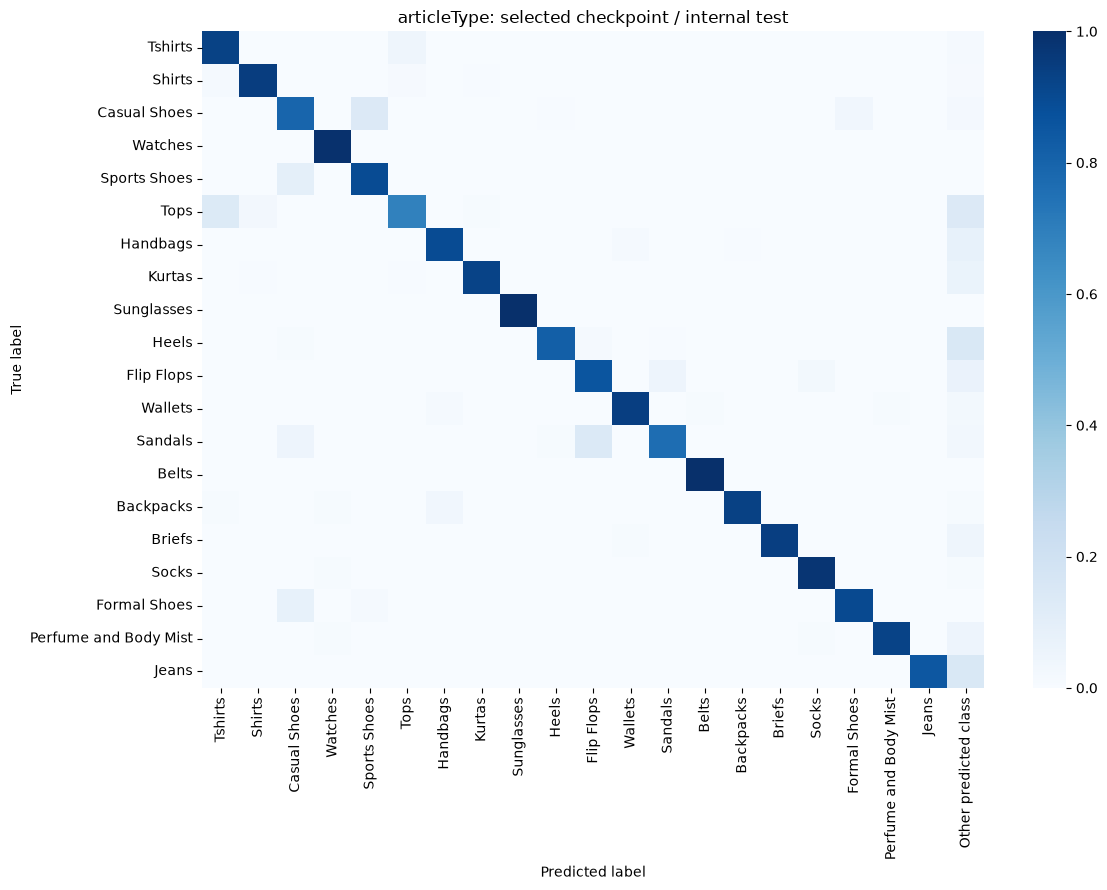

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
directory = RESULTS
stem = stem_for('articleType')
result = test_results['articleType']
labels = result['labels']
shown = task_frame('articleType', 'train')['articleType'].value_counts().head(20).index.tolist()
indices = [labels.index(label) for label in shown]
others = [i for i in range(len(labels)) if i not in indices]
matrix = confusion_matrix(result['truth'], result['predictions'], labels=np.arange(len(labels)))
counts = np.column_stack([matrix[indices][:, indices], matrix[indices][:, others].sum(1)])
normalized = counts / np.maximum(counts.sum(1, keepdims=True), 1)
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(normalized, xticklabels=shown + ['Other predicted class'], yticklabels=shown, cmap='Blues', vmin=0, vmax=1, ax=ax)
ax.set(xlabel='Predicted label', ylabel='True label')
ax.set_title(f"{'articleType'}: selected checkpoint / internal test")
fig.tight_layout()
fig.savefig(FIGURES / f'{stem}_confusion.png', dpi=160, bbox_inches='tight')
plt.show()

## 6. Ultimate Judgement

**Selected-model performance summary**

| Target | Selected model | Validation accuracy | Validation macro-F1 | Internal-test accuracy | Internal-test macro-F1 | Internal-test ECE | Verdict |
|---|---|---:|---:|---:|---:|---:|---|
| Article type | CNN (`cnn_continue_weighted`) | 87.00% | 0.6954 | 86.34% | 0.6373 | 0.0116 | Strongest validation macro-F1 with fewer parameters; rare-class recall remains limited. |

Validation refers to the model-selection view; the decision prioritizes macro-F1, then accuracy, then fewer parameters. Internal-test metrics describe the selected export after calibration and were not used to rank these candidates. The internal test has prior development exposure. Lower ECE indicates closer aggregate confidence?accuracy agreement, not guaranteed class-wise reliability.

**Comparison of the three model families**

The final decision compares the best measured configuration within each of the three model families. The tables summarize the restored best-macro-F1 epochs; the decision prioritizes validation macro-F1, then accuracy, then fewer parameters. Internal-test scores are reported only after selection.

| Model family | Training accuracy | Validation accuracy | Training loss | Validation loss | Validation macro-F1 |
|---|---:|---:|---:|---:|---:|
| Shallow MLP | 75.82% | 74.21% | 0.8186 | 0.9979 | 0.4432 |
| Deeper MLP | 68.99% | 71.86% | 1.0610 | 1.0149 | 0.3160 |
| CNN (selected) | 96.34% | 87.00% | 0.1329 | 0.5412 | 0.6954 |

Training enables dropout and augmentation, while validation uses inference mode. Training accuracy can therefore be lower than validation accuracy. Weighted CNN training loss and unweighted validation loss use different weighting; their raw gap is not a direct overfitting measure. Continuation histories count additional epochs from the original restored CNN weights. Validation macro-F1 averages only classes with positive ground-truth support.


In [19]:
winner = comparisons['articleType'].loc[winners['articleType']]
baseline = comparisons['articleType'].loc[comparisons['articleType']['family'].eq('shallow_mlp')].iloc[0]
display(pd.Series({'selected_method': winners['articleType'], 'selection_macro_f1': winner.validation_macro_f1, 'selection_accuracy': winner.validation_accuracy, 'macro_f1_gain_over_baseline': winner.validation_macro_f1 - baseline.validation_macro_f1, 'internal_test_accuracy': test_results['articleType']['metrics']['accuracy'], 'internal_test_macro_f1': test_results['articleType']['metrics']['macro_f1']}, name='articleType'))

selected_method                cnn_continue_weighted
selection_macro_f1                          0.695401
selection_accuracy                              0.87
macro_f1_gain_over_baseline                 0.252199
internal_test_accuracy                      0.863414
internal_test_macro_f1                      0.637272
Name: articleType, dtype: object

### 6.1. Decision Analysis

The selected CNN gives the strongest balance of overall recognition and minority-class coverage. Its validation macro-F1 of **0.6954** exceeds the tuned shallow MLP's **0.4432** and deeper MLP's **0.3160**. The shallow model is the stronger dense baseline, showing that adding dense layers did not improve this task. The CNN also uses only **684,604 parameters**, compared with approximately 9.5 million for each MLP. Its advantage is consistent with the usefulness of local spatial structure, although these experiments do not identify which visual features individual filters learned.

The tuning evidence supports the specific selected configuration rather than a general claim that more training always helps. Ordinary continuation did not beat the original four-block CNN. Class-weighted continuation increased validation macro-F1 from **0.6664 to 0.6954**, while accuracy changed from **87.10% to 87.00%**. This small accuracy trade-off is acceptable under the declared macro-F1 rule. The best continuation epoch records 96.34% training accuracy versus 87.00% selection accuracy, indicating a remaining generalization gap despite regularization.

Performance is uneven across product types. Tshirts have **92.97% recall** on 512 selection examples, while Bangle and Jackets have only **15.38%** and **45.45% recall** on 13 and 22 examples. Thirteen selection-supported classes have zero recall, and only **97 of 124 output classes** occur in selection. The aggregate score therefore does not establish reliable recognition of every catalogue category.

After model selection, separate calibration and policy groups determine confidence handling. Temperature scaling is retained at **T=1.473**. The internal-test ECE is **0.0116**, NLL is 0.4498, and Brier score is 0.1969. These measure different aspects of probability quality; low aggregate ECE does not guarantee reliable confidence in every class. The saved review threshold is **0.50**, chosen under a 90% accuracy target and minimum 100 policy examples. That policy target is an empirical selection condition, not a guarantee for future images.

The selected `cnn_continue_weighted` model is saved as **`models/article_type_model.keras`**, with label order, preprocessing and confidence metadata. Loading and prediction checks passed. Its descriptive internal-test accuracy is **86.34%** and macro-F1 is **0.6373**. Because the internal test has prior development exposure, these results do not establish independent real-world performance. Public web deployment and the Task 4 submission remain outside the completed validation scope.

The article model also supplies hidden-layer features for visual search. Classification quality motivates using this representation, but does not establish retrieval quality: Task 4 must regenerate and evaluate the gallery against these exact model weights. The saved policy additionally flags article predictions that change under the configured brightness perturbations.


## 7. Final Prediction

Save the selected model, reload it, and predict a sample image. Exported metadata allows the standalone prediction scripts and web application to apply the same preprocessing and confidence policy.


In [20]:
def save_checkpoint(checkpoint, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path = path.with_suffix(".keras")
    model = checkpoint["model"]
    metadata = {key: value for key, value in checkpoint.items() if key != "model"}
    metadata = json.loads(json.dumps(metadata, default=lambda value: value.item()))
    model.get_layer("metadata").metadata = metadata
    # Export architecture, learned weights and metadata without optimizer slots.
    inference_model = keras.models.clone_model(model)
    inference_model.set_weights(model.get_weights())
    inference_model.save(path)
    return path

In [21]:
stem, method = (stem_for('articleType'), winners['articleType'])
path = save_checkpoint(checkpoints['articleType'], OUTPUT / f'{stem}_model.keras')
histories['articleType'][method].to_csv(RESULTS / f'{stem}_history.csv', index=False)
summary = dict(target='articleType', selected=method, cnn_selected=ranked(tuning['articleType']).index[0], framework='tensorflow_keras', model_file=path.name, test_metrics=test_results['articleType']['metrics'], split_sizes={name: len(frame) for name, frame in frames['articleType'].items()}, test_scope='internal_test_with_prior_development_exposure')
(RESULTS / f'{stem}_summary.json').write_text(json.dumps(summary, indent=2) + '\n')
print('Saved', path)

Saved /mnt/d/khoile/programs/fashion-intelligence-classification/models/article_type_model.keras


### 7.1. Load the Saved Model & Predict

A successful reload checks the saved architecture and metadata. This example is a functional check, not an independent quality estimate.


In [22]:
def resolve_classifier_path(path):
    path = Path(path)
    if path.exists():
        return path
    raise FileNotFoundError(f"Missing trained classifier: {path}. Run the classification notebook first.")

def load_checkpoint(path):
    path = resolve_classifier_path(path)
    if path.suffix == ".keras":
        model = keras.models.load_model(path, compile=False)
        return {**dict(model.get_layer("metadata").metadata), "model": model}
    raise ValueError(f"Unsupported classifier format: {path.suffix}")

In [23]:
predictor = FashionClassifier(OUTPUT / f"{stem_for('articleType')}_model.keras")
with Image.open(frames['articleType']['selection'].image_path.iloc[0]) as image:
    print(predictor.predict(image))

{'target': 'articleType', 'label': 'Sports Shoes', 'confidence': 0.9827626688028257, 'top_k': [{'label': 'Sports Shoes', 'confidence': 0.9827626688028257}, {'label': 'Casual Shoes', 'confidence': 0.01704937531165471}, {'label': 'Sports Sandals', 'confidence': 4.547471467294551e-05}], 'needs_review': False, 'review_threshold': 0.5, 'confidence_calibrated': True}


## 8. Conclusion

This task compared a shallow MLP baseline, a deeper MLP and CNN configurations using RGB images, shared preprocessing and frozen product-group partitions. Training-only statistics and separate selection, calibration and policy groups limit leakage between fitting and evaluation. The experiment tests the supplied catalogue labels; it does not establish performance on arbitrary consumer photographs.

The selected model is **`cnn_continue_weighted`**. Its internal-test accuracy of **86.34%** and macro-F1 of **0.6373** describe the final exported classifier, while the validation comparison above explains why it was selected. The result supports this configuration over the alternatives tested here, while the remaining class-wise errors prevent a claim of uniformly reliable recognition.

**Key insights**

- Spatial modelling matters in this comparison: the CNN improves macro-F1 substantially while using far fewer parameters than flattened MLPs.
- A better baseline changes the interpretation: reducing the shallow MLP learning rate raises its macro-F1, yet the CNN still leads by a clear margin.
- Class weighting offers a measured trade-off, improving macro-F1 with a small decrease in validation accuracy; rare categories remain a major limitation.

**Practical outcome and next steps.** The trained classifier is exported and can be loaded by the prediction scripts without retraining. The next priorities are better evidence for rare product categories and independent validation across photographic conditions. Visual-search evaluation and gallery regeneration remain necessary before making retrieval claims. No course-test submission or public-deployment validation is claimed in this notebook.
